In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD12.db")
import snspd
params = snspd.snspd('snspd12.yaml')

# Set up experiment
exp_name = 'SNSPD12_29_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260529-2772-qcodes.log
Experiment loaded. Last ID no: 6


In [3]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml')

In [22]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("osc", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

In [23]:
params.initialize_station()

In [11]:
p_att

<Keithley2000: dmm_keithley>

Bias connected SIG to SIG and GND to GND (positive configuration)

In [16]:
params = snspd.snspd('snspd11.yaml')
params.initialize_station()
params.capture_trace(MS, dmm, yoko, p_att=p_att)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 3. 
3
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;960.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #3, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

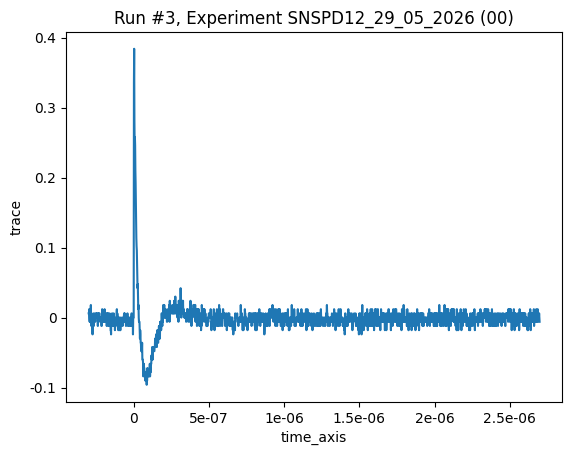

In [17]:
plot_by_id(3)

In [18]:
params = snspd.snspd('snspd11.yaml')
params.initialize_station()
params.capture_trace(MS, dmm, yoko, p_att=p_att)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 4. 
4
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.0450E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #4, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

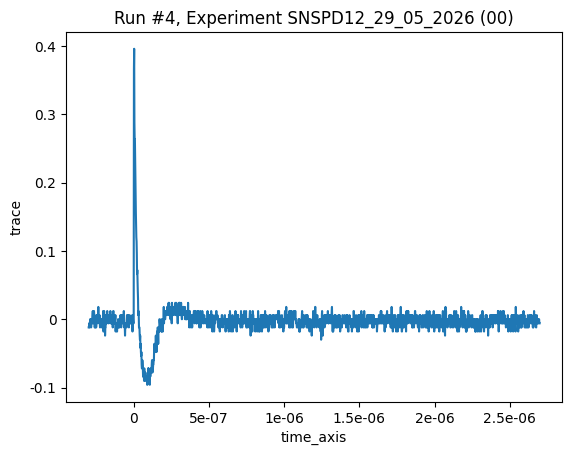

In [19]:
plot_by_id(4)

Positive current giving positive trace. 

In [20]:
laser.enable()

False

In [30]:
currents = [-i for i in params.device_line_1['currents']]

In [32]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
currents = [-i for i in params.device_line_1['currents']]
params.critical_current(currents=currents, device_name=params.device_line_1['name'])

Ramping to 0
update station
Starting experimental run with id: 6. 
6
Starting current -0.0
Starting current 2.5e-07
Starting current 5e-07
Starting current 7.5e-07
Starting current 1e-06
Starting current 1.25e-06
Starting current 1.5e-06
Starting current 1.75e-06
Starting current 2e-06
Starting current 2.25e-06
Starting current 2.5e-06
Starting current 2.75e-06
Starting current 3e-06
Starting current 3.25e-06
Starting current 3.5e-06
Starting current 3.75e-06
Starting current 4e-06
Starting current 4.25e-06
Starting current 4.5e-06
Starting current 4.75e-06
Starting current 5e-06
Starting current 5.25e-06
Starting current 5.5e-06
Starting current 5.75e-06
Starting current 6e-06
Starting current 6.25e-06
Starting current 6.5e-06
Starting current 6.75e-06
Starting current 7e-06
Starting current 7.25e-06
Starting current 7.5e-06
Starting current 7.75e-06
Starting current 8e-06
Starting current 8.25e-06
Starting current 8.5e-06
Starting current 8.75e-06
Starting current 9e-06
Starting curr

Yoko is connected in reverse polarity: signal is applied to GND (accident). But why would we have to apply negative current to see a pulse?  

([<Axes: title={'center': 'Run #6, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='Voltage (mV)'>],
 [None])

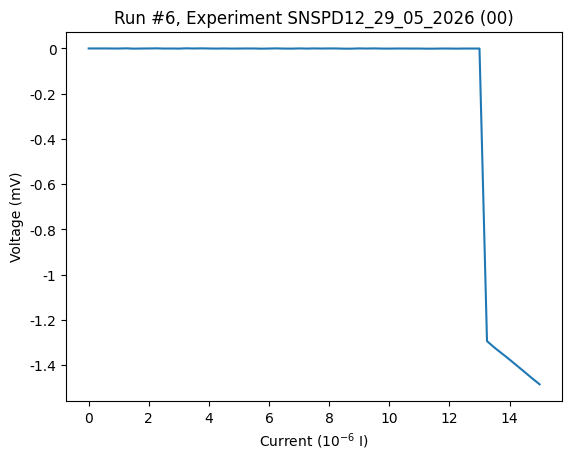

In [33]:
plot_by_id(6)

Swapped polarity on yoko bias. Negative current range will be used. 

In [24]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(5)

for i in params.device_line_1['currents']: 
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att)

Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 8. 
8
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 9. 
9
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 10. 
10
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 11. 
11
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 3

In [25]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)

Ramping to 0


Need to re-take the data where there is no pulse with a lower threshold. Adding functionality to manually set trigger in trace capture function. The highest current where trace not visible is [-3.75e-06]. Will override value in config to be 0.03 (clears noise floor as visible on curves) 

In [33]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml') # reload with new value 

In [34]:
params.trace_v_trigger

'100e-3'

In [45]:
params.initialize_station()
yoko.current(-3e-6)
for trigger in [0.03, 0.04, 0.05]:
    time.sleep(10)
    params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=trigger)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 73. 
73
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.280E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 74. 
74
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;480.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 75. 
75
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #75, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

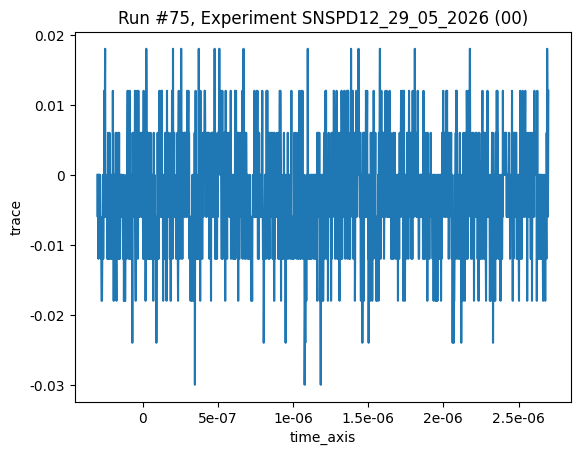

In [48]:
plot_by_id(75) # on the screen for ID 75 can see flickering peak. Also trigger set to 40mV not 50. DOesn't appear to like 50mV will only do 40mV.

Reducing threshold from 50mV to 30mV loses peak, too close to noise floor. Run with 48mV threshold. 

In [49]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(5)

for i in params.device_line_1['currents'][:18]: # Including current of interest
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=48e-3)

Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 76. 
76
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 77. 
77
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 78. 
78
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 79. 
79
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC couplin

The highest current where trace not visible is [-3.75e-06]. Will override value in config to be 0.03 (clears noise floor as visible on curves) 

In [51]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)

Ramping to 0


Swapped polarity, now need to apply negative currents to see positive pulse. Observed that applying positive currents in this configuration led to a transition after 20uA! Need to do both positive and negative sweep.

In [52]:
step = -np.diff(params.device_line_1['currents'])[0]
currents = np.arange(0, 25e-6 + step, step)

In [53]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)

params.critical_current(currents=currents, device_name=params.device_line_1['name'])

Ramping to 0
update station
Starting experimental run with id: 94. 
94
Starting current 0.0
Starting current 2.5e-07
Starting current 5e-07
Starting current 7.5e-07
Starting current 1e-06
Starting current 1.25e-06
Starting current 1.5e-06
Starting current 1.75e-06
Starting current 2e-06
Starting current 2.25e-06
Starting current 2.5e-06
Starting current 2.75e-06
Starting current 3e-06
Starting current 3.25e-06
Starting current 3.5e-06
Starting current 3.75e-06
Starting current 4e-06
Starting current 4.25e-06
Starting current 4.5e-06
Starting current 4.75e-06
Starting current 5e-06
Starting current 5.25e-06
Starting current 5.5e-06
Starting current 5.75e-06
Starting current 6e-06
Starting current 6.25e-06
Starting current 6.5e-06
Starting current 6.75e-06
Starting current 7e-06
Starting current 7.25e-06
Starting current 7.5e-06
Starting current 7.75e-06
Starting current 8e-06
Starting current 8.25e-06
Starting current 8.5e-06
Starting current 8.75e-06
Starting current 9e-06
Starting cur

In [54]:
# Negative sweep 
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)

# Set currents 
currents = [-i for i in currents]
time.sleep(120)
params.critical_current(currents=currents, device_name=params.device_line_1['name'])

Ramping to 0
update station
Starting experimental run with id: 95. 
95
Starting current -0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current -8.5e-06
Starting current -8.75e-06

In [56]:
# Negative sweep 
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)

Ramping to 0


In [58]:
yoko.current(-5e-6)

In [59]:
yoko.current()

-5e-06

In [60]:
# Negative sweep 
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

# Set currents 
currents = [-i for i in currents]
params.critical_current(currents=currents, device_name=params.device_line_1['name'])

Ramping to 0
update station
Starting experimental run with id: 96. 
96
Starting current 0.0
Starting current 2.5e-07
Starting current 5e-07
Starting current 7.5e-07
Starting current 1e-06
Starting current 1.25e-06
Starting current 1.5e-06
Starting current 1.75e-06
Starting current 2e-06
Starting current 2.25e-06
Starting current 2.5e-06
Starting current 2.75e-06
Starting current 3e-06
Starting current 3.25e-06
Starting current 3.5e-06
Starting current 3.75e-06
Starting current 4e-06
Starting current 4.25e-06
Starting current 4.5e-06
Starting current 4.75e-06
Starting current 5e-06
Starting current 5.25e-06
Starting current 5.5e-06
Starting current 5.75e-06
Starting current 6e-06
Starting current 6.25e-06
Starting current 6.5e-06
Starting current 6.75e-06
Starting current 7e-06
Starting current 7.25e-06
Starting current 7.5e-06
Starting current 7.75e-06
Starting current 8e-06
Starting current 8.25e-06
Starting current 8.5e-06
Starting current 8.75e-06
Starting current 9e-06
Starting cur

In [61]:
# Negative sweep 
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0


In [62]:
step = -np.diff(params.device_line_1['currents'])[0]
currents = np.arange(0, 25e-6 + step, step)

# Negative sweep 
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

# Set currents 
currents = [-i for i in currents]
params.critical_current(currents=currents, device_name=params.device_line_1['name'])

Ramping to 0
update station
Starting experimental run with id: 97. 
97
Starting current -0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current -8.5e-06
Starting current -8.75e-06